In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/README.dataset.txt
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/README.roboflow.txt
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid/7dac7803-22f6-4399-8f05-ba4543e3af8d_png.rf.0cf9082145c0dabd2349b36f594d109e.jpg
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid/empty-modern-hospital-room-with-oxygen-concentrator-modern-medical-equipment-in-the-intensive_png_jpg.rf.2e2241800663d288f8ada183e44047eb.jpg
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid/tool_test21_jpeg_jpg.rf.6971e3c7d57940f80fdea60322e140e7.jpg
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid/hcgbhavnagar_micu_mon-403_2022_5_18_9_20_0_jpeg_jpg.rf.b7eab5e55909484d92fc2af0c974269c.jpg
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid/4fc8de61-884d-4ea3-ac5e-eb7c737efa3b_png_jpg.rf.4ae309ecbfb762730e708b59f7a6a82a.jpg
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid/

In [2]:
import os
import json
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Using device: cuda
Torch version: 2.9.0+cu126
Torchvision version: 0.24.0+cu126


In [3]:
DATASET_ROOT = "/kaggle/input/datasets/georgelukaanya/hospitalcocoversion"

TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, "train")
VAL_IMG_DIR   = os.path.join(DATASET_ROOT, "valid")
TEST_IMG_DIR  = os.path.join(DATASET_ROOT, "test")

TRAIN_JSON = os.path.join(TRAIN_IMG_DIR, "_annotations.coco.json")
VAL_JSON   = os.path.join(VAL_IMG_DIR, "_annotations.coco.json")
TEST_JSON  = os.path.join(TEST_IMG_DIR, "_annotations.coco.json")

print(TRAIN_JSON)
print(VAL_JSON)
print(TEST_JSON)

/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/train/_annotations.coco.json
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid/_annotations.coco.json
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/test/_annotations.coco.json


In [4]:
with open(TRAIN_JSON, "r") as f:
    train_coco = json.load(f)

with open(VAL_JSON, "r") as f:
    val_coco = json.load(f)

with open(TEST_JSON, "r") as f:
    test_coco = json.load(f)

print("Train images:", len(train_coco["images"]))
print("Val images:", len(val_coco["images"]))
print("Test images:", len(test_coco["images"]))
print("Train annotations:", len(train_coco["annotations"]))

Train images: 5195
Val images: 272
Test images: 146
Train annotations: 8745


,class_id,class_name,train_count
0,1,Monitor,2185
1,3,bed,1930
2,6,sofa,1285
3,8,tools_table,895
4,7,stool,850
5,2,Saline Stand,770
6,5,chair,720
7,4,bin,110
8,0,tool,0


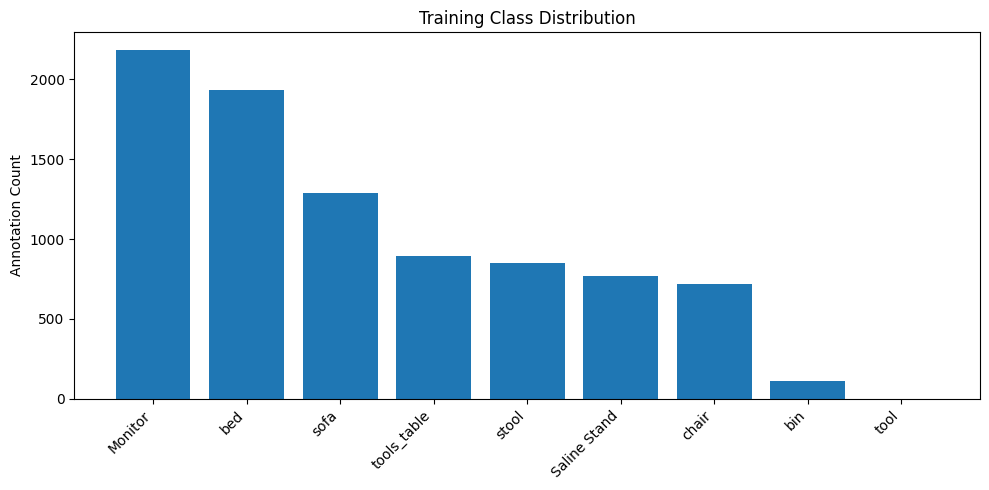

Imbalance ratio: 19.86 :1


In [5]:
cat_id_to_name = {cat["id"]: cat["name"] for cat in train_coco["categories"]}
cat_name_to_id = {cat["name"]: cat["id"] for cat in train_coco["categories"]}

train_class_counts = Counter(ann["category_id"] for ann in train_coco["annotations"])

class_df = pd.DataFrame([
    {
        "class_id": cid,
        "class_name": cat_id_to_name[cid],
        "train_count": train_class_counts.get(cid, 0)
    }
    for cid in sorted(cat_id_to_name.keys())
]).sort_values("train_count", ascending=False).reset_index(drop=True)

display(class_df)

plt.figure(figsize=(10, 5))
plt.bar(class_df["class_name"], class_df["train_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Annotation Count")
plt.title("Training Class Distribution")
plt.tight_layout()
plt.show()

nonzero_counts = class_df[class_df["train_count"] > 0]["train_count"]
print("Imbalance ratio:", round(nonzero_counts.max() / nonzero_counts.min(), 2), ":1")

In [6]:
train_image_id_to_anns = defaultdict(list)
for ann in train_coco["annotations"]:
    train_image_id_to_anns[ann["image_id"]].append(ann)

train_images = train_coco["images"]

# inverse frequency class weights
class_weights = {}
for cid in cat_id_to_name.keys():
    count = train_class_counts.get(cid, 0)
    class_weights[cid] = 1.0 / count if count > 0 else 0.0

# normalize weights
nonzero = [w for w in class_weights.values() if w > 0]
mean_w = np.mean(nonzero)
for cid in class_weights:
    if class_weights[cid] > 0:
        class_weights[cid] /= mean_w

# assign image weights based on rarest class in image
image_weights = []
for img in train_images:
    img_id = img["id"]
    anns = train_image_id_to_anns[img_id]
    if len(anns) == 0:
        image_weights.append(1.0)
    else:
        img_weight = max(class_weights[ann["category_id"]] for ann in anns)
        image_weights.append(img_weight)

image_weights = np.array(image_weights, dtype=np.float32)

print("Image weights summary")
print("Min:", image_weights.min())
print("Max:", image_weights.max())
print("Mean:", image_weights.mean())

Image weights summary
Min: 0.2313445
Max: 4.595343
Mean: 0.51593053


In [7]:
class HospitalCocoDetectionDataset(Dataset):
    def __init__(self, coco_dict, img_dir, train=False):
        self.coco = coco_dict
        self.img_dir = img_dir
        self.train = train

        self.images = coco_dict["images"]
        self.annotations = coco_dict["annotations"]
        self.categories = coco_dict["categories"]

        self.image_id_to_anns = defaultdict(list)
        for ann in self.annotations:
            self.image_id_to_anns[ann["image_id"]].append(ann)

        self.cat_ids = sorted([cat["id"] for cat in self.categories])
        self.cat_id_to_label = {cat_id: i + 1 for i, cat_id in enumerate(self.cat_ids)}
        self.label_to_cat_id = {v: k for k, v in self.cat_id_to_label.items()}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id = img_info["id"]
        img_path = os.path.join(self.img_dir, img_info["file_name"])

        image = Image.open(img_path).convert("RGB")
        image = F.to_tensor(image)

        anns = self.image_id_to_anns[img_id]

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            x, y, w, h = ann["bbox"]

            if w <= 1 or h <= 1:
                continue

            boxes.append([x, y, x + w, y + h])
            labels.append(self.cat_id_to_label[ann["category_id"]])
            areas.append(w * h)
            iscrowd.append(ann.get("iscrowd", 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.train:
            image, target = self.apply_transforms(image, target)

        return image, target

    def apply_transforms(self, image, target):
        _, h, w = image.shape

        # horizontal flip
        if random.random() < 0.5:
            image = torch.flip(image, dims=[2])
            boxes = target["boxes"].clone()
            boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
            target["boxes"] = boxes

        # mild brightness / contrast jitter
        if random.random() < 0.3:
            image = F.adjust_brightness(image, random.uniform(0.9, 1.1))
            image = F.adjust_contrast(image, random.uniform(0.9, 1.1))

        return image, target

In [8]:
train_dataset = HospitalCocoDetectionDataset(train_coco, TRAIN_IMG_DIR, train=True)
val_dataset   = HospitalCocoDetectionDataset(val_coco, VAL_IMG_DIR, train=False)
test_dataset  = HospitalCocoDetectionDataset(test_coco, TEST_IMG_DIR, train=False)

def collate_fn(batch):
    return tuple(zip(*batch))

train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(image_weights),
    num_samples=len(image_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    sampler=train_sampler,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2598
Val batches: 136
Test batches: 73


In [9]:
num_hospital_classes = len(train_coco["categories"])
num_classes = num_hospital_classes + 1  # +1 for background

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)
print("Model ready. Number of classes including background:", num_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 178MB/s]


Model ready. Number of classes including background: 10


In [10]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [11]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

    return running_loss / len(loader)

In [12]:
@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.train()
    running_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        running_loss += losses.item()

    return running_loss / len(loader)

In [13]:
num_epochs = 10

train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model_path = "/kaggle/working/best_faster_rcnn.pth"

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    lr_scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print("  Saved best model.")

print("Training complete.")
print("Best model saved to:", best_model_path)

Epoch 1/10
  Train Loss: 0.2003
  Val Loss:   0.1608
  Saved best model.
Epoch 2/10
  Train Loss: 0.0993
  Val Loss:   0.1596
  Saved best model.
Epoch 3/10
  Train Loss: 0.0809
  Val Loss:   0.1725
Epoch 4/10
  Train Loss: 0.0679
  Val Loss:   0.1534
  Saved best model.
Epoch 5/10
  Train Loss: 0.0661
  Val Loss:   0.1691
Epoch 6/10
  Train Loss: 0.0394
  Val Loss:   0.1659
Epoch 7/10
  Train Loss: 0.0330
  Val Loss:   0.1656
Epoch 8/10
  Train Loss: 0.0309
  Val Loss:   0.1694
Epoch 9/10
  Train Loss: 0.0287
  Val Loss:   0.1702
Epoch 10/10
  Train Loss: 0.0274
  Val Loss:   0.1740
Training complete.
Best model saved to: /kaggle/working/best_faster_rcnn.pth


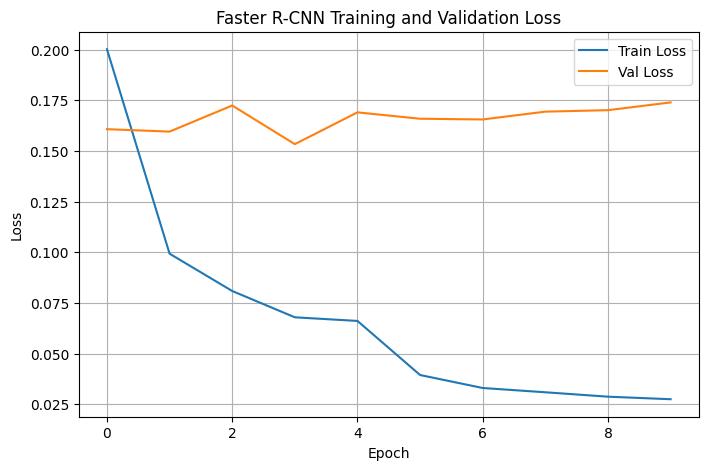

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faster R-CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()
print("Loaded best model.")

Loaded best model.


In [16]:
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - inter_area
    return inter_area / union if union > 0 else 0.0

In [17]:
label_to_cat_id = train_dataset.label_to_cat_id

@torch.no_grad()
def evaluate_per_class_recall(model, loader, device, score_thresh=0.5, iou_thresh=0.5):
    model.eval()

    gt_counts = Counter()
    tp_counts = Counter()

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            gt_boxes = target["boxes"].numpy()
            gt_labels = target["labels"].numpy()

            pred_boxes = output["boxes"].cpu().numpy()
            pred_labels = output["labels"].cpu().numpy()
            pred_scores = output["scores"].cpu().numpy()

            keep = pred_scores >= score_thresh
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]

            used_preds = set()

            for gt_idx, (gt_box, gt_label) in enumerate(zip(gt_boxes, gt_labels)):
                gt_counts[gt_label] += 1

                best_iou = 0.0
                best_pred_idx = -1

                for pred_idx, (pred_box, pred_label) in enumerate(zip(pred_boxes, pred_labels)):
                    if pred_idx in used_preds:
                        continue
                    if pred_label != gt_label:
                        continue

                    iou = compute_iou(gt_box, pred_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_pred_idx = pred_idx

                if best_iou >= iou_thresh and best_pred_idx != -1:
                    tp_counts[gt_label] += 1
                    used_preds.add(best_pred_idx)

    rows = []
    for label, gt_count in sorted(gt_counts.items()):
        tp = tp_counts.get(label, 0)
        recall = tp / gt_count if gt_count > 0 else 0.0
        cat_id = label_to_cat_id[label]
        rows.append({
            "label": label,
            "class_name": cat_id_to_name[cat_id],
            "gt_count": gt_count,
            "tp": tp,
            "recall": recall
        })

    return pd.DataFrame(rows).sort_values("recall", ascending=True)

In [18]:
recall_df = evaluate_per_class_recall(
    model,
    val_loader,
    device,
    score_thresh=0.5,
    iou_thresh=0.5
)

display(recall_df)

,label,class_name,gt_count,tp,recall
3,5,bin,2,0,0.000000
7,9,tools_table,47,35,0.744681
4,6,chair,36,29,0.805556
0,2,Monitor,102,85,0.833333
5,7,sofa,64,54,0.843750
1,3,Saline Stand,41,35,0.853659
6,8,stool,44,40,0.909091
2,4,bed,80,73,0.912500


In [19]:
import matplotlib.patches as patches

def show_predictions(model, dataset, index=0, score_thresh=0.5):
    model.eval()

    image, target = dataset[index]
    image_device = image.to(device)

    with torch.no_grad():
        output = model([image_device])[0]

    image_np = image.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    # Ground truth
    ax[0].imshow(image_np)
    ax[0].set_title("Ground Truth")
    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.numpy()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        ax[0].add_patch(rect)
        class_name = cat_id_to_name[label_to_cat_id[label.item()]]
        ax[0].text(x1, y1, class_name, fontsize=10, bbox=dict(facecolor="yellow", alpha=0.5))

    # Predictions
    ax[1].imshow(image_np)
    ax[1].set_title("Predictions")
    boxes = output["boxes"].cpu().numpy()
    labels = output["labels"].cpu().numpy()
    scores = output["scores"].cpu().numpy()

    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        ax[1].add_patch(rect)
        class_name = cat_id_to_name[label_to_cat_id[label]]
        ax[1].text(x1, y1, f"{class_name} {score:.2f}", fontsize=10,
                   bbox=dict(facecolor="cyan", alpha=0.5))

    plt.tight_layout()
    plt.show()

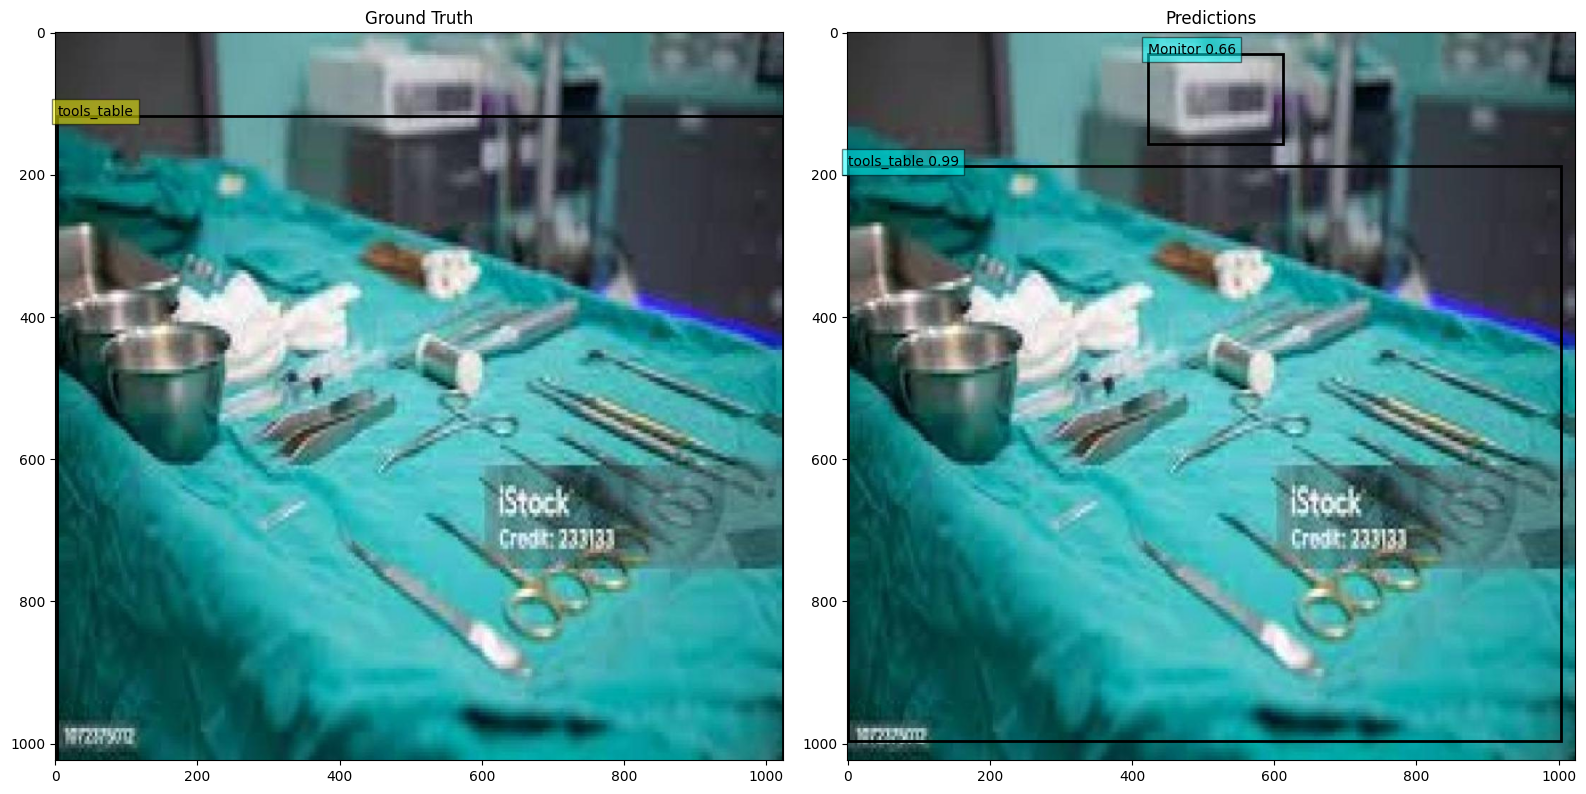

In [20]:
show_predictions(model, val_dataset, index=0, score_thresh=0.5)

In [21]:
final_model_path = "/kaggle/working/faster_rcnn_final.pth"
torch.save(model.state_dict(), final_model_path)

recall_df.to_csv("/kaggle/working/val_per_class_recall.csv", index=False)

print("Saved:")
print(final_model_path)
print("/kaggle/working/val_per_class_recall.csv")

Saved:
/kaggle/working/faster_rcnn_final.pth
/kaggle/working/val_per_class_recall.csv


In [22]:
!pip install -q torchmetrics

In [23]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [24]:
@torch.no_grad()
def evaluate_map(model, loader, device):
    model.eval()
    
    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
        class_metrics=True
    )

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        preds = []
        gts = []

        for output, target in zip(outputs, targets):
            preds.append({
                "boxes": output["boxes"].cpu(),
                "scores": output["scores"].cpu(),
                "labels": output["labels"].cpu()
            })

            gts.append({
                "boxes": target["boxes"].cpu(),
                "labels": target["labels"].cpu()
            })

        metric.update(preds, gts)

    results = metric.compute()
    return results

In [25]:
map_results = evaluate_map(model, val_loader, device)

for k, v in map_results.items():
    print(k, v)

map tensor(0.5336)
map_50 tensor(0.7486)
map_75 tensor(0.6177)
map_small tensor(0.)
map_medium tensor(0.1746)
map_large tensor(0.5465)
mar_1 tensor(0.5692)
mar_10 tensor(0.6559)
mar_100 tensor(0.6559)
mar_small tensor(0.)
mar_medium tensor(0.2000)
mar_large tensor(0.6624)
map_per_class tensor([0.4280, 0.6074, 0.6457, 0.0589, 0.6455, 0.7149, 0.7409, 0.4272])
mar_100_per_class tensor([0.5627, 0.6854, 0.7237, 0.3500, 0.7139, 0.7844, 0.8273, 0.6000])
classes tensor([2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.int32)


In [26]:
@torch.no_grad()
def evaluate_per_class_metrics(model, loader, device, score_thresh=0.5, iou_thresh=0.5):
    model.eval()

    gt_counts = Counter()
    tp_counts = Counter()
    fp_counts = Counter()

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            gt_boxes = target["boxes"].numpy()
            gt_labels = target["labels"].numpy()

            pred_boxes = output["boxes"].cpu().numpy()
            pred_labels = output["labels"].cpu().numpy()
            pred_scores = output["scores"].cpu().numpy()

            keep = pred_scores >= score_thresh
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]

            matched_gt = set()

            for gt_box, gt_label in zip(gt_boxes, gt_labels):
                gt_counts[gt_label] += 1

            for pred_idx, (pred_box, pred_label) in enumerate(zip(pred_boxes, pred_labels)):
                best_iou = 0.0
                best_gt_idx = -1

                for gt_idx, (gt_box, gt_label) in enumerate(zip(gt_boxes, gt_labels)):
                    if gt_idx in matched_gt:
                        continue
                    if gt_label != pred_label:
                        continue

                    iou = compute_iou(gt_box, pred_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = gt_idx

                if best_iou >= iou_thresh and best_gt_idx != -1:
                    tp_counts[pred_label] += 1
                    matched_gt.add(best_gt_idx)
                else:
                    fp_counts[pred_label] += 1

    rows = []
    all_labels = sorted(set(list(gt_counts.keys()) + list(tp_counts.keys()) + list(fp_counts.keys())))

    for label in all_labels:
        tp = tp_counts.get(label, 0)
        fp = fp_counts.get(label, 0)
        gt = gt_counts.get(label, 0)
        fn = gt - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / gt if gt > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        fnr = fn / gt if gt > 0 else 0.0

        cat_id = label_to_cat_id[label]
        rows.append({
            "label": label,
            "class_name": cat_id_to_name[cat_id],
            "gt_count": gt,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "false_negative_rate": fnr
        })

    return pd.DataFrame(rows).sort_values("recall")

In [27]:
metrics_df = evaluate_per_class_metrics(
    model,
    val_loader,
    device,
    score_thresh=0.5,
    iou_thresh=0.5
)

display(metrics_df)

,label,class_name,gt_count,tp,fp,fn,precision,recall,f1_score,false_negative_rate
3,5,bin,2,0,3,2,0.000000,0.000000,0.000000,1.000000
7,9,tools_table,47,35,13,12,0.729167,0.744681,0.736842,0.255319
4,6,chair,36,29,7,7,0.805556,0.805556,0.805556,0.194444
0,2,Monitor,102,85,65,17,0.566667,0.833333,0.674603,0.166667
5,7,sofa,64,54,13,10,0.805970,0.843750,0.824427,0.156250
1,3,Saline Stand,41,35,26,6,0.573770,0.853659,0.686275,0.146341
6,8,stool,44,40,11,4,0.784314,0.909091,0.842105,0.090909
2,4,bed,80,73,41,7,0.640351,0.912500,0.752577,0.087500


In [28]:
import time

@torch.no_grad()
def measure_inference_speed(model, loader, device, num_batches=20):
    model.eval()
    times = []

    for i, (images, _) in enumerate(loader):
        if i >= num_batches:
            break

        images = [img.to(device) for img in images]

        torch.cuda.synchronize() if torch.cuda.is_available() else None
        start = time.time()

        _ = model(images)

        torch.cuda.synchronize() if torch.cuda.is_available() else None
        end = time.time()

        times.append(end - start)

    avg_time = np.mean(times)
    fps = 1.0 / avg_time if avg_time > 0 else 0.0

    return {
        "avg_time_per_batch_sec": avg_time,
        "fps_estimate": fps
    }

In [29]:
speed_results = measure_inference_speed(model, val_loader, device)

print(speed_results)

{'avg_time_per_batch_sec': np.float64(0.09884518384933472), 'fps_estimate': np.float64(10.11683079596731)}
